<a href="https://colab.research.google.com/github/Martinmbiro/variational-autoencoder/blob/main/01.%20VAE%20from%20scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coding a Variational AutoEncoder (VAE)
This notebook entails coding a vanilla Variational AutoEncoder (VAE), training it and analyzing the results
+ I begin by configuring the system environment, and loading the FashionMNIST dataset.
+ The model's architecture relies on simple fully-connected [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) layers
+ The encoder network compresses the 784-pixel flattened images into a 128-dimensional latent space, and the decoder network that reconstructs the images using [`nn.ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html) and [`nn.Sigmoid`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) activation functions.

### Getting started
> Here, we install necessary libraries, import relevant modules and download the EMNIST dataset

In [ ]:
# install pytorch lightning, torchinfo
!pip install -qU lightning torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 16.3 MB/s eta 0:00:00


In [ ]:
# imports
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.transforms.v2 as T
import torch.optim as optim

from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from torchinfo import summary

import matplotlib.pyplot as plt, numpy as np, pandas as pd
import plotly.express as px
import os

from pathlib import Path

import lightning

In [ ]:
# import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# torch.autograd.set_detect_anomaly(True)

In [ ]:
# define device
if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'

# display device
print(f'Device: {device}')

Device: cpu


#### Downloading the FashionMNIST dataset
> Here, we download the dataset and apply transforms

In [ ]:
# define image transforms
img_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(dtype=torch.float32, scale=True)
])

# download MNIST dataset
data = datasets.FashionMNIST(
    root='mnist_data', train=True, download=True, transform=img_transforms
)

# create a subset of the dataset
# (purely for faster training, since I was using slower free GPU)
# data = Subset(dataset=data,
#               indices=np.random.randint(0, len(data), 5000))


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.6MB/s]


In [ ]:
# display size of dataset
print(f'Size of dataset: {len(data)}')

Size of dataset: 60000


#### Creating `DataLoader` from data
> The `DataLoader` helps us pass data to the model during training operations

In [ ]:
# define batch size
BATCH_SIZE = 128

# data loader
train_loader = DataLoader(
    dataset=data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=os.cpu_count(),
    pin_memory=False
)

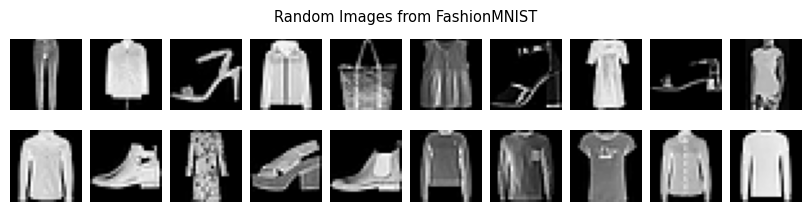

In [ ]:
# random indices from dataset
rand_indices = np.random.randint(0, len(data), 20)

f, axs = plt.subplots(2, 10, figsize=(8,3), layout='compressed')
for i, ax in zip(rand_indices, axs.flat):
  img, _ = data[i]
  ax.imshow(img.permute(1,2,0), cmap='gray')
  ax.axis(False)
f.suptitle('Random Images from FashionMNIST', fontsize=10.5)
plt.show()

### Coding the VAE
+ Here, we'll have the network constitute of [`nn.Linear`](https://docs.pytorch.org/docs/2.12/generated/torch.nn.Linear.html#torch.nn.Linear) layers

🔔 **Recall**  
From the ReadME section of this repository, we established that:
+ The enoder network outputs two vectors, $μ$ and $log(σ^2)$
+ $log(σ^2) = $ `logvar`
+ $z = μ + σ * ϵ$
+ $σ = e^{0.5 \cdot logvar}$ = `std`


In [ ]:
INPUT_DIM, HIDDEN_DIM, LATENT_DIM  = 784, 256, 128

class VAE(nn.Module):
  def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM,
               hidden_dim=HIDDEN_DIM):
    super().__init__()
    # encoder layers
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    # decoder layers
    self.fc2 = nn.Linear(latent_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, input_dim)

  # --ENCODE------
  def encode(self, x):
    h = F.relu(self.fc1(x))
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    return mu, logvar

  # --DECODE------
  def decode(self, z):
    h = F.relu(self.fc2(z))
    out = F.sigmoid(self.fc3(h))
    return out

  # --RE-PARAMETERIZE
  def reparameterize(self, mu, logvar):
    # std = sqrt(exp(logvar))
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    # Reparameterization trick: z = mu + eps(std)
    z = mu + eps * std
    return z

  # --FORWARD-----
  def forward(self, x):
    # predict mu & logvar
    mu, logvar = self.encode(x)

    # sample from latent space
    z = self.reparameterize(mu, logvar)

    # reconstruct input from z
    x_recon = self.decode(z)
    return x_recon, mu, logvar

In [ ]:
# initialize the model
torch.manual_seed(123)

vae = VAE()

#### Defining the Loss Function
> This is the loss we shall use to optimize our model's parameters. It will be used inside of our `LightningModule` class that we define later

🔔 **Recall**  
From the ReadME section of this repository, we established that the ELBO loss constitutes of two terms; (Reconstruction term + Regularization term)
+ Reconstruction loss
>+ Binary Cross Entropy (BCE) Loss
+ Regularization term defined by **KL Divergence**
>+ $-\frac{1}{2} (1 + log(σ^2) - μ^2 - σ^2)$
+ $σ^2 = e^{logvar}$
+ $log(σ^2) = $ `logvar`



In [ ]:
# loss function
def vae_loss(x_recon, x, mu, logvar):
    # 1. Reconstruction loss
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    # 2. KL Divergence (Analytical formula for two Gaussians)
    # -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total sum of losses
    total_loss =  recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

#### Untrained VAE inference
Here, we perform inference using the VAE in its untrained state, to compare the results later


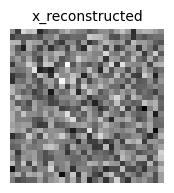

In [ ]:
# get random image from dataset
x, _ = data[np.random.randint(0, len(data))]

# perform inference
with torch.inference_mode():
  x = x.to(device).view(-1, 784)
  vae.to(device), vae.eval()
  x_recon, _, _ = vae(x)
  x_recon = x_recon.view(-1, 28, 28).cpu()

# plot
plt.figure(figsize=(2, 2))
plt.title("x_reconstructed", fontsize=10)
plt.imshow(x_recon.permute(1,2,0), cmap='gray')
plt.axis(False)
plt.show()

📝 **Note**  
+ As expected, the model outputs gibberish since the weights and biases have not been optimized yet

#### Visualizing VAE summary
> Here, we use `torchinfo.summary` to visualize a summary of the model's layers, and tensor output shapes

In [ ]:
# sample input (with batch dimension)
sample_input = torch.randn(1, 1, 28, 28)

# visualize model summary
summary(vae, input_data=sample_input.view(-1, 784).to(device))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 784]                  --
├─Linear: 1-1                            [1, 256]                  200,960
├─Linear: 1-2                            [1, 128]                  32,896
├─Linear: 1-3                            [1, 128]                  32,896
├─Linear: 1-4                            [1, 256]                  33,024
├─Linear: 1-5                            [1, 784]                  201,488
Total params: 501,264
Trainable params: 501,264
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.50
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.01
Estimated Total Size (MB): 2.02

### Set up Pytorch Lightning
> Pytorch lightning provides a high-level interface for PyTorch training and scaling

#### Add a [`LightningModule`](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html)
The LightningModule is the full recipe that defines how your `nn.Modules` interact.
+ The [`training_step`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.training_step) defines how the `nn.Module`(s) interact together.
+ In the [`configure_optimizers`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.configure_optimizers) define the optimizer(s) for your models.

🔔 **Note**  
> Here, we'll also use a learning rate scheduler that incorporates a warm-up phase as well:  [`get_cosine_schedule_with_warmup`](https://huggingface.co/docs/transformers/main_classes/optimizer_schedules#transformers.get_cosine_schedule_with_warmup) - from Huggingface `transformers` package

In [ ]:
from transformers import get_cosine_schedule_with_warmup

In [ ]:
class LitModule(lightning.LightningModule):
  def __init__(self, model:nn.Module):
    super().__init__()
    self.model = model

  # loss function
  def vae_loss(self, x_recon, x, mu, logvar):
    # 1. Reconstruction loss
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    # 2. KL Divergence (Analytical formula for two Gaussians)
    # -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total sum of losses
    total_loss =  recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

  def training_step(self, batch, batch_idx):
    x, _ = batch
    x = x.view(-1, 784)

    # forward pass
    x_recon, mu, logvar = self.model(x)
    # calculate loss
    train_loss, recon_loss, kl_loss = self.vae_loss(x_recon, x, mu, logvar)

    # log loss
    self.log_dict(
        dictionary={'train_loss':train_loss, 'recon_loss':recon_loss, 'kl_loss':kl_loss},
        prog_bar=True, on_step=False, on_epoch=True
      )
    return train_loss

  def configure_optimizers(self):
    # total training steps (batches)
    total_steps = self.trainer.estimated_stepping_batches

    # optimizer
    optimizer = optim.AdamW(params=self.parameters(), lr=1e-3)
    # lr scheduler
    scheduler = get_cosine_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=(0.1*total_steps),
        num_training_steps=total_steps
    )
    return {
        'optimizer':optimizer,
        'lr_scheduler':{
            'scheduler':scheduler,
            'interval':'step',
            'frequency':1
        }
    }

#### Set up [`EarlyStopping`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.EarlyStopping.html#earlystopping) and [`ModelCheckpoint`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.ModelCheckpoint.html#modelcheckpoint)
+ `EarlyStopping` - Monitors a metric and stop training when it stops improving
+ `ModelCheckpoint` - Save the model after every epoch by monitoring a quantity

In [ ]:
# import
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='train_loss',
    min_delta=1e-3,
    mode='min',
)

model_checkpoint = ModelCheckpoint(
    dirpath=Path.cwd().joinpath('checkpoint'),
    monitor='train_loss',
    mode='min'
)

### Train the model
> Once the PyTorch code has been organized in a `LightningModule`, the [`Trainer`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.trainer.trainer.Trainer.html) automates the core engineering and infrastructure details of training deep learning models
+ It also enables logging using `loggers` such as the [`CSVLogger`](https://lightning.ai/docs/pytorch/stable/extensions/generated/lightning.pytorch.loggers.CSVLogger.html#lightning.pytorch.loggers.CSVLogger)

In [ ]:
from lightning.pytorch.loggers import CSVLogger

# path to save csv file
csv_logger = CSVLogger(save_dir=Path.cwd().joinpath('logs'))

In [ ]:
%%time
# set up trainer object
trainer = lightning.Trainer(
    inference_mode=False,
    max_epochs = 100,
    logger=csv_logger,
    enable_model_summary=False,
    callbacks = [early_stopping, model_checkpoint],
    # detect_anomaly=True
)

# train model
trainer.fit(
    model=LitModule(model=vae),
    train_dataloaders=train_loader
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

Output()

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


CPU times: user 14min 18s, sys: 56.3 s, total: 15min 14s
Wall time: 35min 9s


In [ ]:
# !rm -rf /content/logs
# !rm -rf /content/checkpoint

#### Load model from `Modelcheckpoint`
Here, we load the best trained model from the checkpoint saved by the `ModelCheckpoint` callback
+ To do this, we call [`load_from_checkpoint`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.load_from_checkpoint)

⚠ **Note**
+ Note that this method is a class method, hence one should use the custom `LightningModule` class to call it
+ Any methods passed to the class' constructor (`__init__`) method are also passed here

In [ ]:
# load from checkpoint
from_checkpoint = LitModule.load_from_checkpoint(
    # checkpoint_path=model_checkpoint.best_model_path,
    checkpoint_path='/content/epoch=97-step=45864.ckpt',
    map_location=device,
    model=vae # argument passed to __init__ of the LightningModule class
)

# re-assign vae to best model
vae = from_checkpoint.model

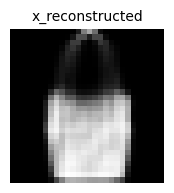

In [ ]:
# reconstruct random input from dataset
x, _ = data[np.random.randint(0, len(data))]

with torch.inference_mode():
  x = x.to(device).view(-1, 784)
  vae.to(device), vae.eval()
  x_recon, _, _ = vae(x)
  x_recon = x_recon.cpu().view(1, 28, 28)

plt.figure(figsize=(2,2))
plt.title('x_reconstructed', fontsize=10)
plt.imshow(x_recon.permute(1,2,0), cmap='gray')
plt.axis(False)
plt.show()

🎆🎊 Seems like we have successfully loaded the right model!

#### Plot training loss across epochs
The `CSVLogger` object creates a `*.csv` file in a directory of choice.
+ Hence, we can read this file using `pandas` and plot the `mse_loss` that we logged during training

In [ ]:
# read the csv containing logs into a DataFrame
# df = pd.read_csv('/content/logs/lightning_logs/version_0/metrics.csv')
df=pd.read_csv('/content/metrics.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   epoch       100 non-null    int64  
 1   kl_loss     100 non-null    float64
 2   recon_loss  100 non-null    float64
 3   step        100 non-null    int64  
 4   train_loss  100 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 4.0 KB


In [ ]:
# display DataFrame
df

,epoch,kl_loss,recon_loss,step,train_loss
0,0,1542.306519,57222.179688,467,58764.507812
1,1,2230.719238,38144.894531,935,40375.617188
2,2,2239.358154,34441.546875,1403,36680.894531
3,3,2180.806152,33314.828125,1871,35495.628906
4,4,2226.179199,32665.015625,2339,34891.187500
...,...,...,...,...,...
95,95,2067.125488,28419.421875,44927,30486.568359
96,96,2066.776123,28417.607422,45395,30484.373047
97,97,2066.821289,28413.082031,45863,30479.923828
98,98,2066.089111,28415.337891,46331,30481.421875


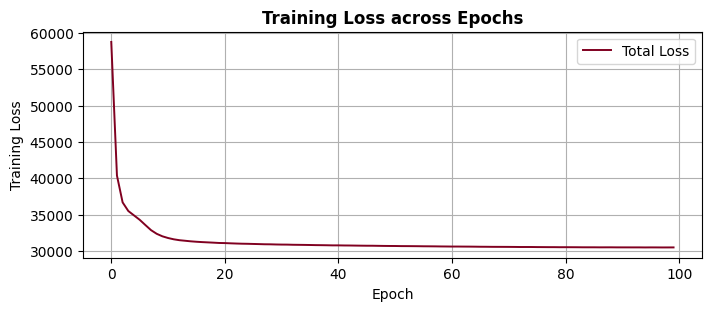

In [ ]:
# plot training Loss vs Epoch
f, ax = plt.subplots(figsize=(7,3), layout='compressed')

ax.plot(df['train_loss'], linewidth=1.4, color='#800020', label='Total Loss')

ax.set_title('Training Loss across Epochs', weight='black')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')

ax.grid()
ax.legend()
plt.show()

#### Ground truth vs reconstructed input
> Here, we plot the ground truth images against reconstructed images

In [ ]:
# set model to eval, move to device
vae.eval()
vae.to(device);

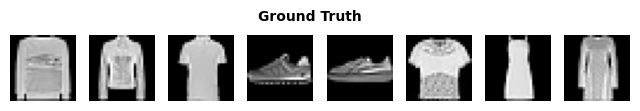

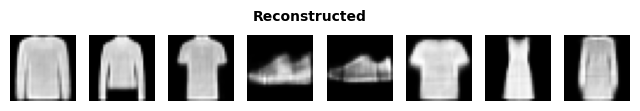

In [ ]:
# generate random indices from dataset
rand_indices = torch.randint(0, len(data), (8,))

# plot ground truths (x):
f, axs = plt.subplots(1, 8, figsize=(8,2))
for i, ax in zip(rand_indices, axs.flat):
  x, _ = data[i]
  ax.imshow(x.permute(1,2,0), cmap='gray')
  ax.axis(False)
f.suptitle('Ground Truth', y=0.79, fontsize=10, weight='black')

# plot x_reconstructed:
f, axs = plt.subplots(1, 8, figsize=(8,2))
for i, ax in zip(rand_indices, axs.flat):
  with torch.inference_mode():
    x, _ = data[i]
    x = x.to(device)
    x_recon, _, _ = vae(x.view(-1, 784))
    x_recon = x_recon.view(-1, 28, 28).cpu()

  ax.imshow(x_recon.permute(1,2,0), cmap='gray')
  ax.axis(False)
f.suptitle('Reconstructed', y=0.79, fontsize=10, weight='black')
plt.show()

### Visualizing the latent space
Since the latent dimension, `LATENT_DIM` is more than 3 dimensions, it's hard to visualize it as it is.
+ Hence, we shall make use of [`sklearn`](http://scikit-learn.org/) Principal Component Analysis [(PCA)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#pca) to bin down the `LATENT_DIM` dimensions into 2 and 3 dimension for plotting

In [ ]:
latents, labels = [], []

vae.to(device), vae.eval()
with torch.inference_mode():
  for x, y in train_loader:
    labels.append(y)
    x = x.to(device).view(-1, 784)

    mu, logvar = vae.encode(x)
    z = vae.reparameterize(mu, logvar)
    latents.append(z)

  labels = torch.cat(labels, dim=0)
  latents = torch.cat(latents, dim=0)

In [ ]:
# shape of tensors produced
latents.shape, labels.shape

(torch.Size([59904, 128]), torch.Size([59904]))

In [ ]:
from sklearn.decomposition import PCA

# ininialize PCA objects: 2D, 3D
pca2, pca3 = PCA(n_components=2), PCA(n_components=3)

# perform PCA on the latent dim to produce 2D & 3D features
Z_pca2 = pca2.fit_transform(latents.detach().cpu().numpy()) # 2D
Z_pca3 = pca3.fit_transform(latents.detach().cpu().numpy()) # 3D

#### In 2D

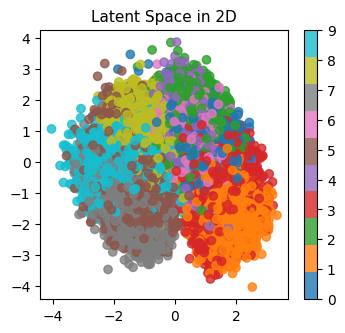

In [ ]:
# create Figure, Axes
plt.figure(figsize=(4,3.5))
plt.title('Latent Space in 2D', fontsize=11)
sc = plt.scatter(Z_pca2[:, 0], Z_pca2[:, 1],
                 c=labels, cmap='tab10', alpha=0.8)

plt.colorbar(sc)
plt.show()

#### In 3D

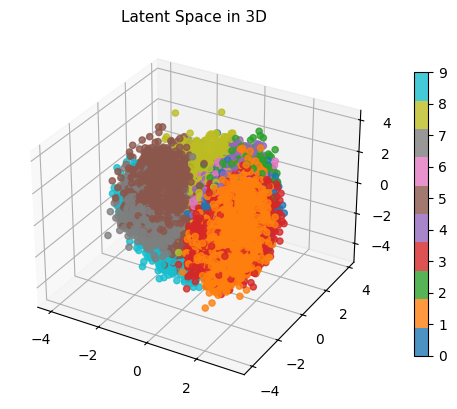

In [ ]:
# -----matplotlib--------
# create Figure, Axes
f, ax = plt.subplots(figsize=(4.5,4.5), layout='constrained',
                     subplot_kw={'projection': '3d'})

scat = ax.scatter(Z_pca3[:, 0], Z_pca3[:, 1], Z_pca3[:, 2],
                  c=labels, cmap='tab10', alpha=0.8)
ax.set_title('Latent Space in 3D', fontsize=11)

f.colorbar(scat, ax=ax, pad=0.1, shrink=0.65)
plt.show()

In [ ]:
# ----plotly------------
# defining a plotly scatter_3d plot:
f = px.scatter_3d(
    x=Z_pca3[:,0], y=Z_pca3[:,1], z=Z_pca3[:,2],
    color=labels, opacity=0.9, color_continuous_scale='inferno'
  )
f.update_traces(marker=dict(size=5))
f.show()

### Sampling a random vector from latent space
> Here, we'll sample random vectors from the latent space, and decode these vectors and plot the result

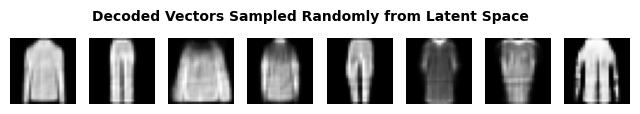

In [ ]:
with torch.inference_mode():
  Zs = torch.randn(8, 1, LATENT_DIM, device=device)
  vae.eval(), vae.to(device)
  x_recons = vae.decode(Zs).cpu().view(-1, 1, 28, 28)

f, axs = plt.subplots(1, 8, figsize=(8, 3))
for x_recon, ax in zip(x_recons, axs.flat):
  ax.imshow(x_recon.permute(1,2,0), cmap='gray')
  ax.axis(False)
f.suptitle('Decoded Vectors Sampled Randomly from Latent Space',
            y=0.7, fontsize=10, weight='black')
plt.show()

🔔 **Note**  
Sampling from the latent space reveals that the vanilla Variational AutoEncoder (VAE) can be considered a generative model (though not perfect) - probably the most primitive form

📝 **Hence**  
A VAE can be used to ouput new data in the form of random variations of the training data $x$